Loading data...
  Rows          : 234
  GDP obs       : 77 quarterly observations
  Date range    : 2005-06-01 to 2024-06-01
  Vintages      : [-2, -1, 0]  (ARMA vintage-invariant)
  ADF test      : stat=-8.210  p=0.000 (stationary)

Building Figure 1...


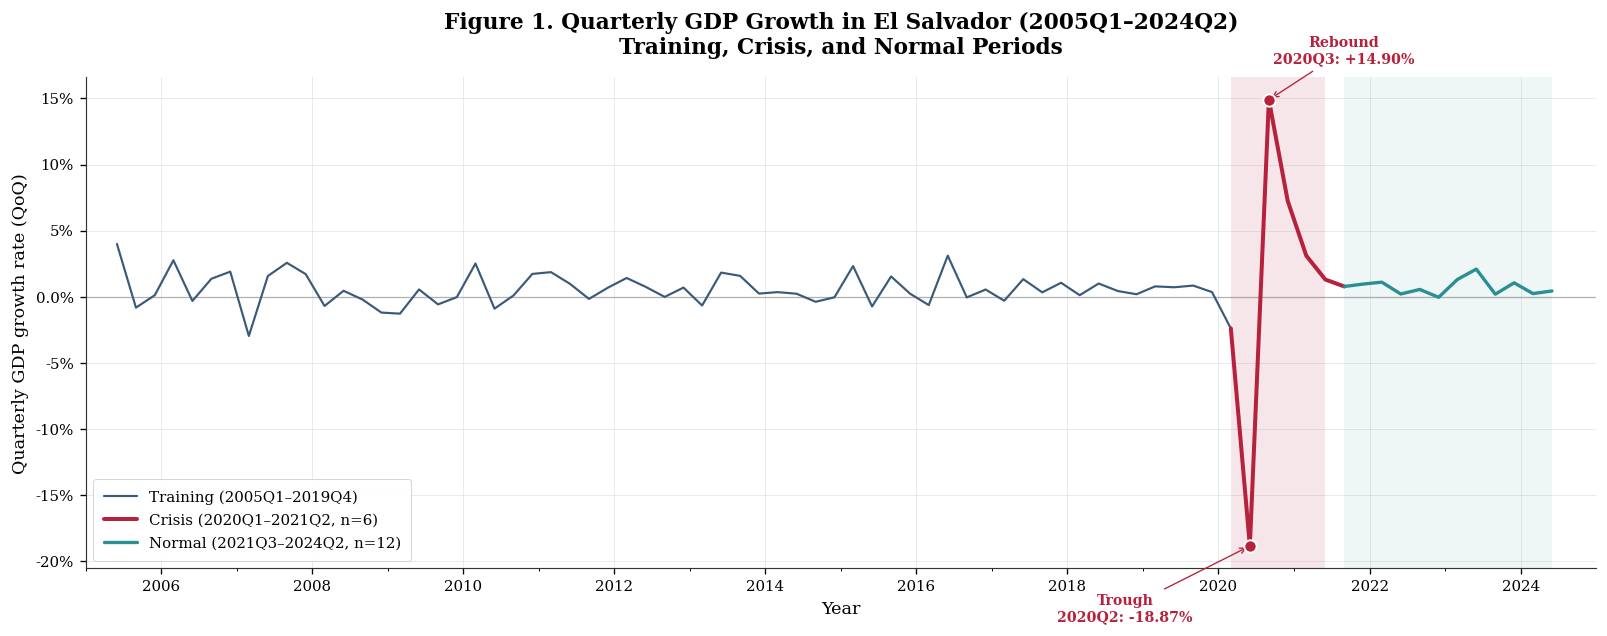

Saved: figure_01_gdp_regime_map.png (and .pdf)

Running rolling-origin ARMA evaluation...
  Test window : 2020-03-01 to 2024-06-01
  Max order   : ARMA(3,3), AIC, exhaustive grid
  GDP pub lag : 3 months

  [2020-03-01]  ARMA(0,1)  n= 59  AIC=-353.98  fcst=+0.0060  actual=-0.0240  LB(p)=0.526
  [2020-06-01]  ARMA(0,1)  n= 60  AIC=-354.55  fcst=+0.0153  actual=-0.1887  LB(p)=0.649
  [2020-09-01]  ARMA(0,1)  n= 61  AIC=-261.50  fcst=-0.0758  actual=+0.1490  LB(p)=1.000
  [2020-12-01]  ARMA(0,1)  n= 62  AIC=-255.31  fcst=-0.0151  actual=+0.0725  LB(p)=1.000
  [2021-03-01]  ARMA(0,2)  n= 63  AIC=-260.15  fcst=-0.0101  actual=+0.0309  LB(p)=1.000
  [2021-06-01]  ARMA(0,2)  n= 64  AIC=-263.52  fcst=-0.0164  actual=+0.0130  LB(p)=0.996
  [2021-09-01]  ARMA(0,2)  n= 65  AIC=-267.84  fcst=-0.0259  actual=+0.0077  LB(p)=0.987
  [2021-12-01]  ARMA(0,2)  n= 66  AIC=-271.80  fcst=-0.0233  actual=+0.0095  LB(p)=0.956
  [2022-03-01]  ARMA(1,1)  n= 67  AIC=-276.20  fcst=-0.0172  actual=+0.0110  LB(p)=

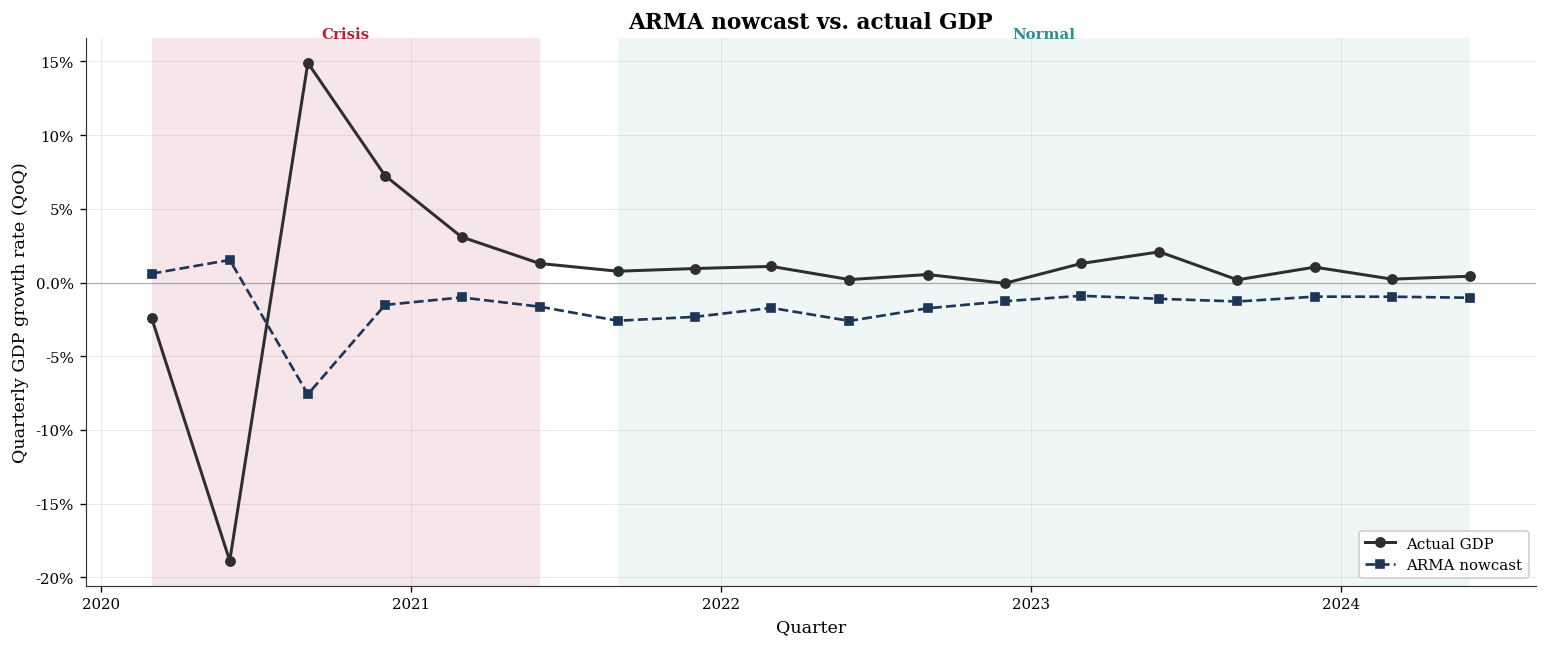

Saved: arma_forecast_vs_actual.png


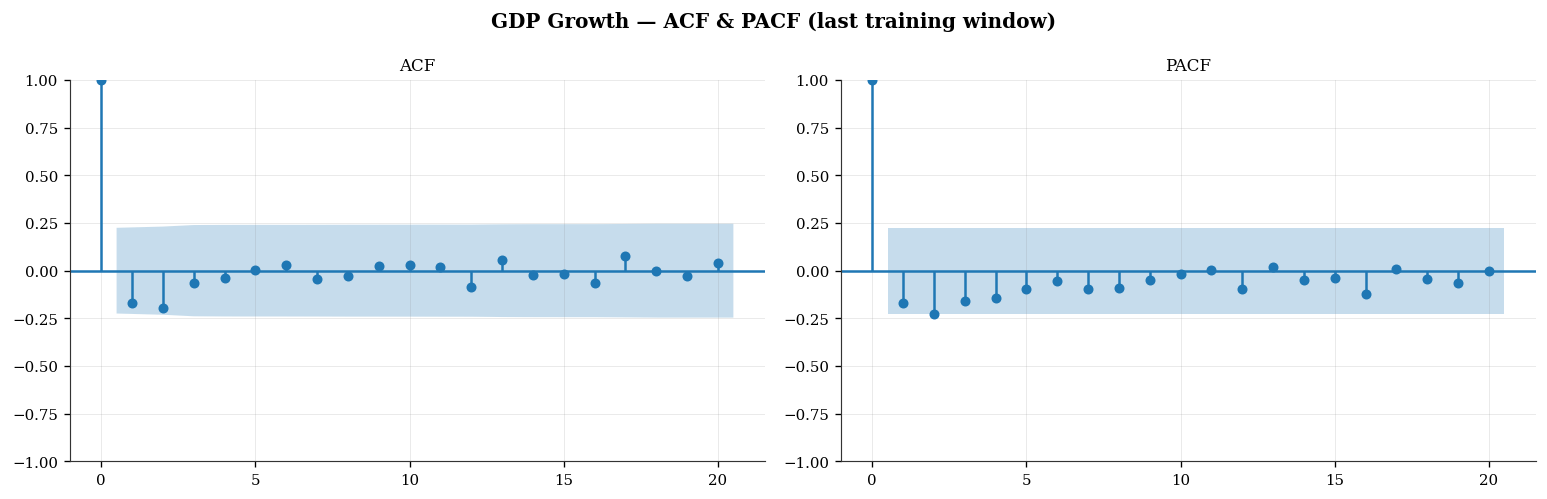

Saved: arma_acf_pacf.png


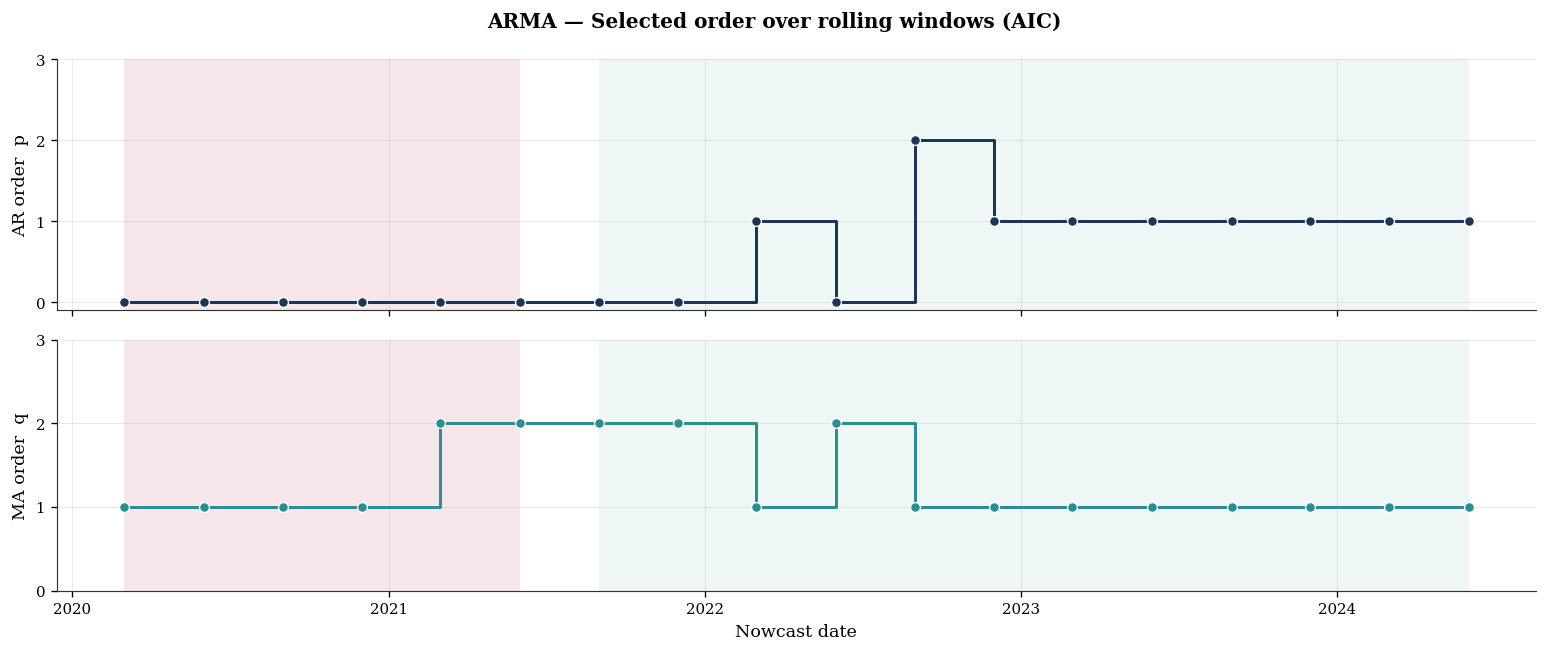

Saved: arma_order_over_time.png

DONE


In [3]:
# =============================================================================
# arma_final.py
# ARMA univariate benchmark for El Salvador GDP nowcasting.
# Primary benchmark against which all other models are compared.
#
# Author : Gabriela Aquino
# =============================================================================

import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

# =============================================================================
# 0. PATHS AND IMPORTS
# =============================================================================
BASE_DIR  = Path.home() / "Desktop" / "ESA-gdp-nowcasting"
DATA_DIR  = BASE_DIR / "Data"
MODEL_DIR = BASE_DIR / "Models"
OUT_DIR   = MODEL_DIR / "results" / "arma"
OUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(MODEL_DIR))

from nowcast_utils import (
    LAGS, TARGET_VARIABLE,
    TEST_START, TEST_END,
    CRISIS_START, CRISIS_END,
    NORMAL_START, NORMAL_END,
    GDP_PUB_LAG, RANDOM_SEED,
    classify_crisis_periods,
    rmse, mae,
)

PATH_DATA = DATA_DIR / "data_tf.csv"
PATH_META = DATA_DIR / "meta_data_v2.csv"
for p in [PATH_DATA, PATH_META]:
    if not p.exists():
        raise FileNotFoundError(f"\n  File not found: {p}")

# =============================================================================
# 1. ARMA HYPERPARAMETERS
# =============================================================================
MAX_P: int = 3
MAX_Q: int = 3
MAX_D: int = 0
np.random.seed(RANDOM_SEED)

# =============================================================================
# 2. PLOTTING STYLE
# =============================================================================
STYLE = {
    "c_training":       "#3A5A7A",
    "c_crisis":         "#B6213B",
    "c_normal":         "#2A8F93",
    "c_forecast":       "#1D3557",
    "c_actual":         "#2E2E2E",
    "zero_line_colour": "#555555",
    "shade_crisis":     0.11,
    "shade_normal":     0.08,
    "grid_colour":      "#888888",
    "grid_alpha":       0.20,
}

plt.rcParams.update({
    "font.family":       "serif",
    "axes.titlesize":    13,
    "axes.labelsize":    10.5,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "axes.grid":         True,
    "grid.alpha":        STYLE["grid_alpha"],
    "grid.color":        STYLE["grid_colour"],
    "grid.linewidth":    0.5,
    "axes.edgecolor":    "#333333",
    "axes.linewidth":    0.7,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        120,
})


def _fmt_pct(x, _pos=None):
    return f"{x * 100:.0f}%" if abs(x) >= 0.01 else f"{x * 100:.1f}%"


def _format_xaxis_years(ax, step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(base=step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))


def _shade_regimes(ax):
    """Add Crisis and Normal shading to any axis."""
    ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
               facecolor=STYLE["c_crisis"], alpha=STYLE["shade_crisis"],
               edgecolor="none", zorder=0)
    ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
               facecolor=STYLE["c_normal"], alpha=STYLE["shade_normal"],
               edgecolor="none", zorder=0)


# =============================================================================
# 3. LOAD DATA
# =============================================================================
print("Loading data...")
data = pd.read_csv(PATH_DATA, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
gdp_series = (
    data[["date", TARGET_VARIABLE]]
    .dropna(subset=[TARGET_VARIABLE])
    .sort_values("date")
    .reset_index(drop=True)
)
print(f"  Rows          : {data.shape[0]}")
print(f"  GDP obs       : {len(gdp_series)} quarterly observations")
print(f"  Date range    : {gdp_series['date'].min().date()} to {gdp_series['date'].max().date()}")
print(f"  Vintages      : {LAGS}  (ARMA vintage-invariant)")

adf_stat, adf_pval, *_ = adfuller(gdp_series[TARGET_VARIABLE].dropna())
print(f"  ADF test      : stat={adf_stat:.3f}  p={adf_pval:.3f}",
      "(stationary)" if adf_pval < 0.05 else "(WARNING: non-stationary)")

test_dates = pd.date_range(TEST_START, TEST_END, freq="3MS").strftime("%Y-%m-%d").tolist()

# =============================================================================
# 4. FIGURE 1 — GDP Growth with regime map
# =============================================================================
print("\nBuilding Figure 1...")

gdp_plot = gdp_series.copy()
gdp_plot["regime"] = "training"
gdp_plot.loc[(gdp_plot["date"] >= pd.to_datetime(CRISIS_START)) &
             (gdp_plot["date"] <= pd.to_datetime(CRISIS_END)), "regime"] = "crisis"
gdp_plot.loc[(gdp_plot["date"] >= pd.to_datetime(NORMAL_START)) &
             (gdp_plot["date"] <= pd.to_datetime(NORMAL_END)), "regime"] = "normal"

n_crisis = (gdp_plot["regime"] == "crisis").sum()
n_normal = (gdp_plot["regime"] == "normal").sum()

fig, ax = plt.subplots(figsize=(13.5, 5.4))
_shade_regimes(ax)
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)


def _plot_segment(regime_name, colour, label, lw=1.5):
    seg = gdp_plot[gdp_plot["regime"] == regime_name].sort_values("date")
    if len(seg) == 0:
        return
    # Extend one observation into next regime for visual continuity
    next_after = gdp_plot[gdp_plot["date"] > seg["date"].max()].head(1)
    plot_seg = pd.concat([seg, next_after]) if len(next_after) > 0 else seg
    ax.plot(plot_seg["date"], plot_seg[TARGET_VARIABLE],
            color=colour, lw=lw, solid_capstyle="round", label=label, zorder=3)


_plot_segment("training", STYLE["c_training"], "Training (2005Q1–2019Q4)",          lw=1.3)
_plot_segment("crisis",   STYLE["c_crisis"],   f"Crisis (2020Q1–2021Q2, n={n_crisis})", lw=2.4)
_plot_segment("normal",   STYLE["c_normal"],   f"Normal (2021Q3–2024Q2, n={n_normal})", lw=2.0)

# Annotate trough and rebound
trough_date  = pd.to_datetime("2020-06-01")
rebound_date = pd.to_datetime("2020-09-01")
trough_val   = gdp_series.loc[gdp_series["date"] == trough_date,  TARGET_VARIABLE].values
rebound_val  = gdp_series.loc[gdp_series["date"] == rebound_date, TARGET_VARIABLE].values

if len(trough_val) > 0:
    ax.scatter(trough_date, trough_val[0], s=55,
               color=STYLE["c_crisis"], edgecolor="white", lw=1.2, zorder=6)
    ax.annotate(f"Trough\n2020Q2: {trough_val[0] * 100:+.2f}%",
                xy=(trough_date, trough_val[0]),
                xytext=(-75, -45), textcoords="offset points",
                ha="center", fontsize=8.5, color=STYLE["c_crisis"], fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=STYLE["c_crisis"], lw=0.8))

if len(rebound_val) > 0:
    ax.scatter(rebound_date, rebound_val[0], s=55,
               color=STYLE["c_crisis"], edgecolor="white", lw=1.2, zorder=6)
    ax.annotate(f"Rebound\n2020Q3: {rebound_val[0] * 100:+.2f}%",
                xy=(rebound_date, rebound_val[0]),
                xytext=(45, 22), textcoords="offset points",
                ha="center", fontsize=8.5, color=STYLE["c_crisis"], fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=STYLE["c_crisis"], lw=0.8))

ax.yaxis.set_major_formatter(plt.FuncFormatter(_fmt_pct))
_format_xaxis_years(ax, step=2)
ax.set_xlim(pd.to_datetime("2005-01-01"), pd.to_datetime("2024-12-31"))
ax.set_xlabel("Year")
ax.set_ylabel("Quarterly GDP growth rate (QoQ)")
ax.set_title("Figure 1. Quarterly GDP Growth in El Salvador (2005Q1–2024Q2)\n"
             "Training, Crisis, and Normal Periods",
             fontweight="bold", pad=14)
legend = ax.legend(loc="lower left", frameon=True, framealpha=0.95,
                   edgecolor="#cccccc", handlelength=2.2, borderpad=0.7, labelspacing=0.6)
legend.get_frame().set_linewidth(0.5)

plt.tight_layout()
fig.savefig(OUT_DIR / "figure_01_gdp_regime_map.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT_DIR / "figure_01_gdp_regime_map.pdf",         bbox_inches="tight")
plt.show()
print("Saved: figure_01_gdp_regime_map.png (and .pdf)")


# =============================================================================
# 5. HELPERS
# =============================================================================
def select_order_aic(series, max_p=MAX_P, max_q=MAX_Q, d=MAX_D):
    """Exhaustive grid search over (p, q) minimising AIC."""
    best_aic, best_order, best_model = np.inf, (0, d, 0), None
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                model = ARIMA(series, order=(p, d, q), trend="c") \
                    .fit(method_kwargs={"warn_convergence": False})
                if np.isfinite(model.aic) and model.aic < best_aic:
                    best_aic, best_order, best_model = model.aic, (p, d, q), model
            except Exception:
                continue
    return best_order, best_model, best_aic


def ljung_box_pvalue(resid, lags=8):
    try:
        lb = acorr_ljungbox(resid, lags=[lags], return_df=True)
        return float(lb["lb_pvalue"].iloc[0])
    except Exception:
        return np.nan


# =============================================================================
# 6. ROLLING-ORIGIN EVALUATION
# =============================================================================
print("\nRunning rolling-origin ARMA evaluation...")
print(f"  Test window : {TEST_START} to {TEST_END}")
print(f"  Max order   : ARMA({MAX_P},{MAX_Q}), AIC, exhaustive grid")
print(f"  GDP pub lag : {GDP_PUB_LAG} months\n")

records = []
last_train_series = None

for nowcast_date in test_dates:
    nd = pd.to_datetime(nowcast_date)
    actual_rows = gdp_series.loc[
        gdp_series["date"].dt.to_period("Q") == nd.to_period("Q"),
        TARGET_VARIABLE
    ]
    if actual_rows.empty:
        print(f"  [{nowcast_date}] No actual GDP — skipping.")
        continue
    actual = float(actual_rows.values[0])

    # Option A: conservative vintage -2 cutoff.
    # With GDP_PUB_LAG = 3, the latest GDP observation realistically
    # available at ANY vintage of the target quarter is the one whose
    # quarter-start date is <= nd - 3 months. Using this common cutoff
    # for all vintages prevents look-ahead bias and makes ARMA's
    # vintage-invariant forecast an honest floor benchmark.
    train_cutoff = nd - pd.DateOffset(months=GDP_PUB_LAG)
    train_series = gdp_series.loc[
        gdp_series["date"] <= train_cutoff, TARGET_VARIABLE
    ].reset_index(drop=True)
    if len(train_series) < 8:
        print(f"  [{nowcast_date}] Only {len(train_series)} obs — skipping.")
        continue

    order, model, aic = select_order_aic(train_series)
    if model is None:
        print(f"  [{nowcast_date}] ALL ORDERS FAILED — skipping.")
        continue

    try:
        forecast_val = float(np.asarray(model.forecast(steps=1)).ravel()[0])
        if not np.isfinite(forecast_val):
            raise ValueError(f"Non-finite forecast: {forecast_val}")
    except Exception as e:
        print(f"  [{nowcast_date}] Forecast FAILED: {type(e).__name__}: {e}")
        continue

    lb_p = ljung_box_pvalue(model.resid, lags=min(8, len(train_series) // 4))

    records.append({
        "date":      nowcast_date,
        "actual":    actual,
        "forecast":  forecast_val,
        "p":         order[0],
        "q":         order[2],
        "aic":       aic,
        "n_train":   len(train_series),
        "lb_pvalue": lb_p,
    })
    last_train_series = train_series.copy()

    flag = " [resid-autocorr!]" if (not np.isnan(lb_p) and lb_p < 0.05) else ""
    print(f"  [{nowcast_date}]  ARMA({order[0]},{order[2]})  "
          f"n={len(train_series):3d}  AIC={aic:7.2f}  "
          f"fcst={forecast_val:+.4f}  actual={actual:+.4f}  "
          f"LB(p)={lb_p:.3f}{flag}")

if not records:
    raise RuntimeError("No successful windows — inspect error messages above.")

df = pd.DataFrame(records)
df["period_type"] = classify_crisis_periods(df["date"].tolist()).values

print("\nPeriod partition:")
print(df["period_type"].value_counts().to_string())

# =============================================================================
# 7. METRICS
# =============================================================================
def metrics_for(subset):
    return {
        "n":    len(subset),
        "RMSE": round(rmse(subset["actual"], subset["forecast"]), 6),
        "MAE":  round(mae(subset["actual"],  subset["forecast"]), 6),
    }

full_m   = metrics_for(df)
crisis_m = metrics_for(df[df["period_type"] == "crisis"])
normal_m = metrics_for(df[df["period_type"] == "normal"])

print("\n" + "=" * 60)
print("ARMA BENCHMARK")
print("=" * 60)
print(f"  Full   (n={full_m['n']:2d}): RMSE={full_m['RMSE']:.6f}  MAE={full_m['MAE']:.6f}")
print(f"  Crisis (n={crisis_m['n']:2d}): RMSE={crisis_m['RMSE']:.6f}  MAE={crisis_m['MAE']:.6f}")
print(f"  Normal (n={normal_m['n']:2d}): RMSE={normal_m['RMSE']:.6f}  MAE={normal_m['MAE']:.6f}")

perf_full = pd.DataFrame([
    {"Vintage": lag, "RMSE": full_m["RMSE"], "MAE": full_m["MAE"], "n": full_m["n"]}
    for lag in LAGS
])

strat_rows = []
for period, mdict, label in [
    ("crisis", crisis_m, "Crisis (2020Q1–2021Q2)"),
    ("normal", normal_m, "Normal (2021Q3–2024Q2)"),
]:
    for lag in LAGS:
        strat_rows.append({
            "Period": label, "Vintage": lag,
            "n": mdict["n"], "RMSE": mdict["RMSE"], "MAE": mdict["MAE"],
        })
perf_strat = pd.DataFrame(strat_rows)

benchmark_table = pd.DataFrame({
    "metric":     ["RMSE_full", "RMSE_crisis", "RMSE_normal",
                   "MAE_full",  "MAE_crisis",  "MAE_normal"],
    "arma_value": [full_m["RMSE"], crisis_m["RMSE"], normal_m["RMSE"],
                   full_m["MAE"],  crisis_m["MAE"],  normal_m["MAE"]],
    "n":          [full_m["n"], crisis_m["n"], normal_m["n"]] * 2,
})

# =============================================================================
# 8. SAVE CSVs
# =============================================================================
pred_table = df.copy()
for lag in LAGS:
    col = f"lag_{'-' if lag < 0 else '+'}{abs(lag)}"
    pred_table[col] = pred_table["forecast"]

pred_table.to_csv(OUT_DIR / "arma_predictions.csv",            index=False)
perf_full.to_csv(OUT_DIR / "arma_performance_full.csv",        index=False)
perf_strat.to_csv(OUT_DIR / "arma_performance_stratified.csv", index=False)
benchmark_table.to_csv(OUT_DIR / "arma_benchmark.csv",         index=False)

diag_fails = df[(df["lb_pvalue"] < 0.05) & df["lb_pvalue"].notna()]
if len(diag_fails) > 0:
    print(f"\n  [WARN] Ljung–Box rejects white noise in {len(diag_fails)}/{len(df)} windows.")
    diag_fails[["date", "p", "q", "lb_pvalue"]].to_csv(
        OUT_DIR / "arma_lb_violations.csv", index=False)
else:
    print("\n  [OK] Ljung–Box: residuals ~ white noise in all windows.")
print(f"\nCSVs saved to: {OUT_DIR}")

# =============================================================================
# 9. DIAGNOSTIC PLOTS
# =============================================================================
print("\nBuilding diagnostic plots...")

# 9.1 Forecast vs Actual
df_plot = df.copy()
df_plot["date"] = pd.to_datetime(df_plot["date"])

fig, ax = plt.subplots(figsize=(13, 5.5))
_shade_regimes(ax)
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)
ax.plot(df_plot["date"], df_plot["actual"],
        color=STYLE["c_actual"], lw=1.8, marker="o", ms=5.5,
        label="Actual GDP", zorder=4)
ax.plot(df_plot["date"], df_plot["forecast"],
        color=STYLE["c_forecast"], lw=1.6, marker="s", ms=5, ls="--",
        label="ARMA nowcast", zorder=5)

y_top = df_plot[["actual", "forecast"]].max().max() * 1.10
for label, start, end, colour in [
    ("Crisis", CRISIS_START, CRISIS_END, STYLE["c_crisis"]),
    ("Normal", NORMAL_START, NORMAL_END, STYLE["c_normal"]),
]:
    mid = pd.to_datetime(start) + (pd.to_datetime(end) - pd.to_datetime(start)) / 2
    ax.text(mid, y_top, label, ha="center", va="bottom",
            fontsize=9, color=colour, fontweight="bold")

ax.yaxis.set_major_formatter(plt.FuncFormatter(_fmt_pct))
_format_xaxis_years(ax, step=1)
ax.set_xlabel("Quarter")
ax.set_ylabel("Quarterly GDP growth rate (QoQ)")
ax.set_title("ARMA nowcast vs. actual GDP", fontweight="bold")
ax.legend(loc="lower right", frameon=True, framealpha=0.95, edgecolor="#cccccc")

plt.tight_layout()
fig.savefig(OUT_DIR / "arma_forecast_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: arma_forecast_vs_actual.png")

# 9.2 ACF / PACF
if last_train_series is not None:
    max_lags = min(20, len(last_train_series) // 2 - 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    fig.suptitle("GDP Growth — ACF & PACF (last training window)", fontweight="bold")
    plot_acf(last_train_series, ax=axes[0], lags=max_lags, alpha=0.05)
    axes[0].set_title("ACF", fontsize=10)
    plot_pacf(last_train_series, ax=axes[1], lags=max_lags, alpha=0.05, method="ywm")
    axes[1].set_title("PACF", fontsize=10)
    for ax_ in axes:
        ax_.grid(alpha=STYLE["grid_alpha"])
    plt.tight_layout()
    fig.savefig(OUT_DIR / "arma_acf_pacf.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: arma_acf_pacf.png")

# 9.3 Order over time
fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
for ax_, col, colour, ylabel in [
    (axes[0], "p", STYLE["c_forecast"], "AR order  p"),
    (axes[1], "q", STYLE["c_normal"],   "MA order  q"),
]:
    _shade_regimes(ax_)
    ax_.step(pd.to_datetime(df["date"]), df[col], color=colour, lw=1.8, where="post")
    ax_.scatter(pd.to_datetime(df["date"]), df[col], color=colour, s=35,
                edgecolor="white", lw=0.8, zorder=4)
    ax_.set_ylabel(ylabel)
    ax_.set_yticks(range(max(MAX_P, MAX_Q) + 1))
    ax_.grid(alpha=STYLE["grid_alpha"])

_format_xaxis_years(axes[1], step=1)
axes[1].set_xlabel("Nowcast date")
fig.suptitle("ARMA — Selected order over rolling windows (AIC)", fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "arma_order_over_time.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: arma_order_over_time.png")

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)
